CLASSIFICATION TASK: Student Performance Prediction
UNSDG 4: Quality Education - Predicting Student Performance Levels

1. DATASET OVERVIEW:
----------------------------------------
Dataset shape: (395, 35)

Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Grade', 'Performance']

Data types:
object     18
int64      16
float64     1
Name: count, dtype: int64

First 5 rows of the dataset:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...

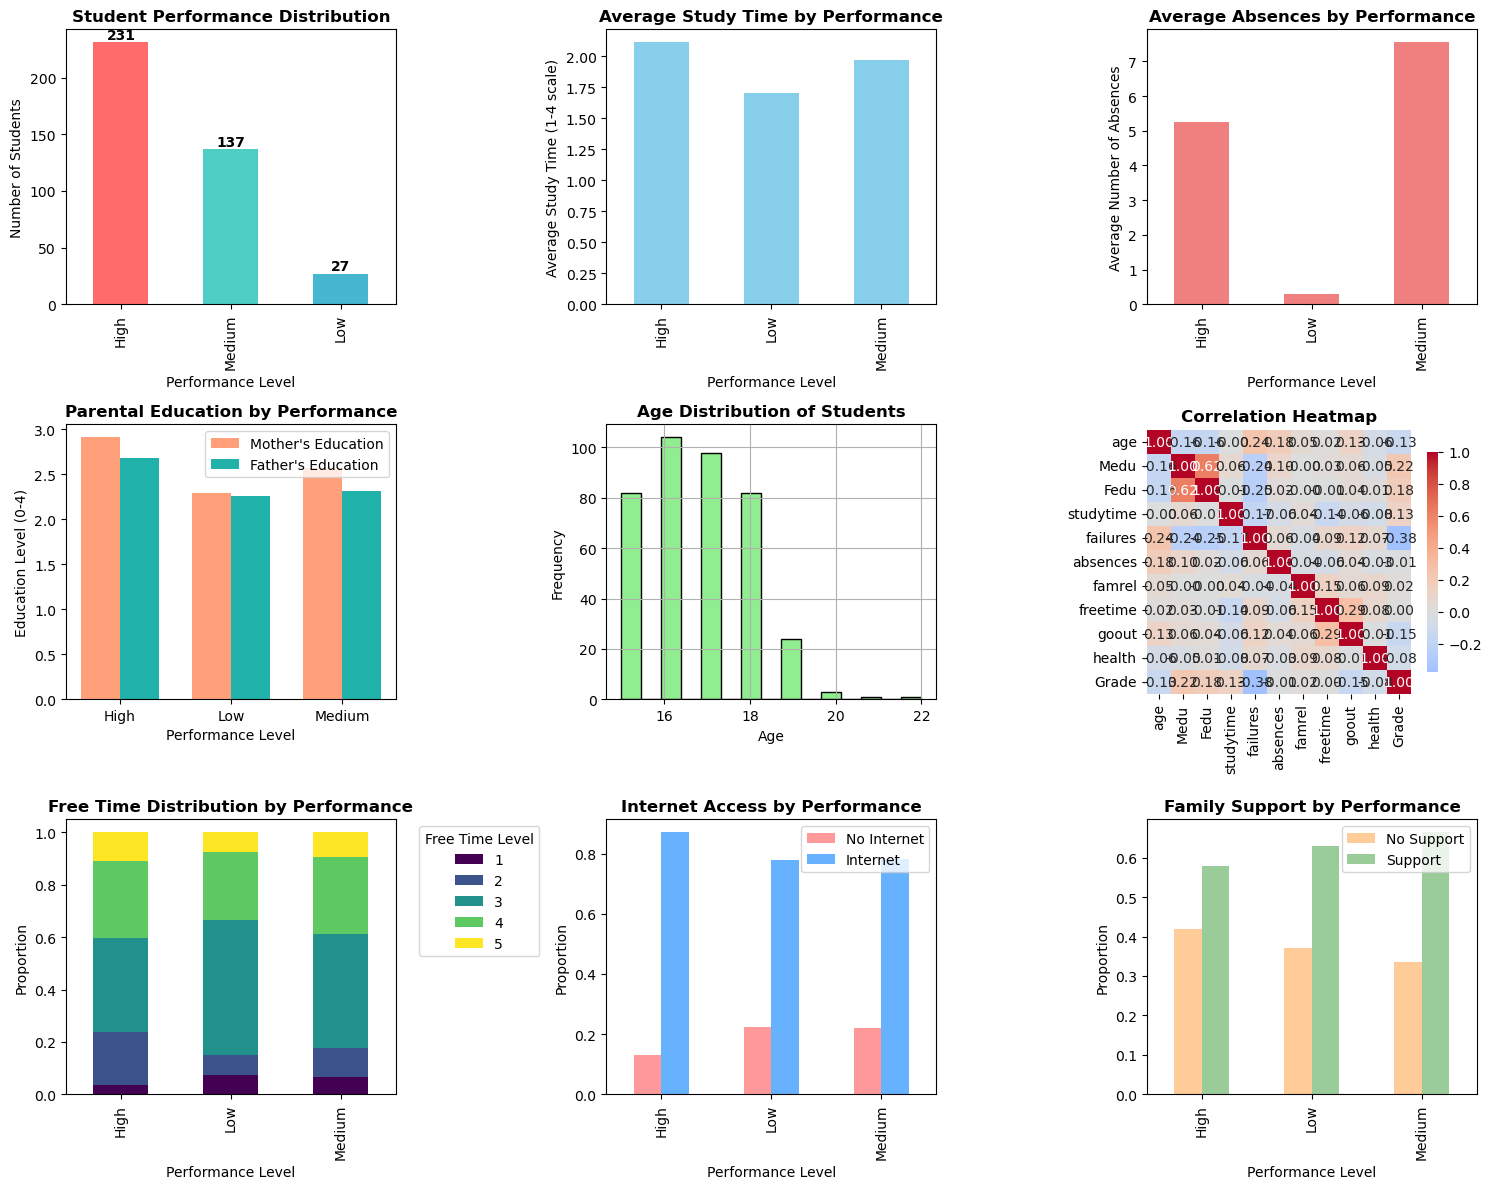


EDA visualizations saved as 'classification_eda_results.png'

NEURAL NETWORK CLASSIFICATION MODEL
Training Neural Network...

NEURAL NETWORK ARCHITECTURE:
----------------------------------------
Input Layer: 30 neurons (features)
Hidden Layer 1: 64 neurons, ReLU activation
Hidden Layer 2: 32 neurons, ReLU activation
Output Layer: 3 neurons (performance levels), Softmax activation
Total Parameters: 4,064
Loss Function: Cross-entropy
Optimizer: Adam (β1=0.9, β2=0.999)
Learning Rate: Adaptive starting at 0.001

PERFORMANCE METRICS:
----------------------------------------
Training Accuracy: 0.8703
Test Accuracy: 0.6203

Test Precision (Weighted): 0.5591
Test Recall (Weighted): 0.6203
Test F1-Score (Weighted): 0.5831

DETAILED CLASSIFICATION REPORT:
----------------------------------------
              precision    recall  f1-score   support

        High       0.67      0.83      0.74        46
         Low       0.00      0.00      0.00         6
      Medium       0.50      0.41     

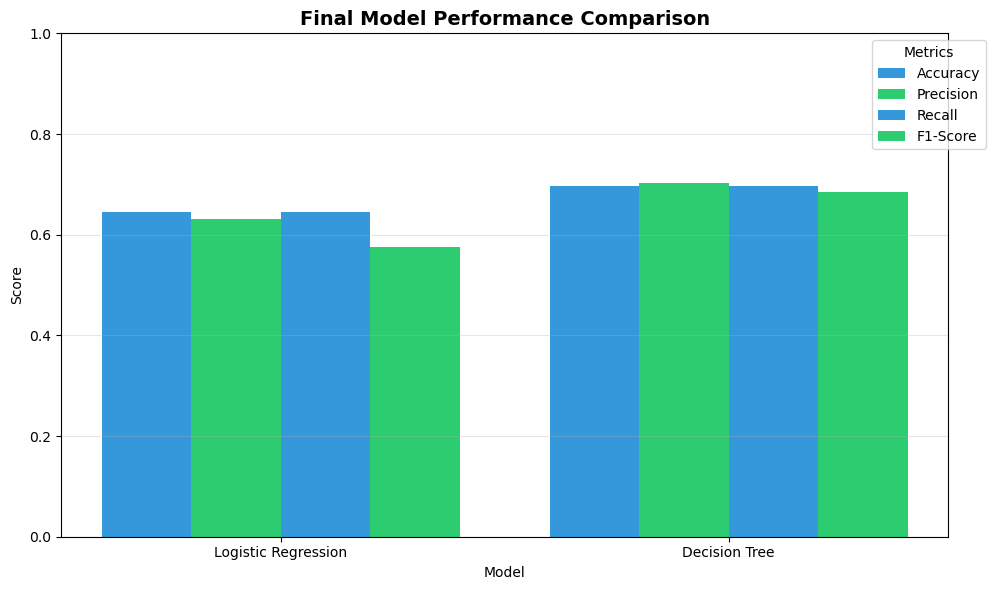


CONCLUSION AND REFLECTION

MODEL PERFORMANCE SUMMARY:
----------------------------------------
Best performing model: Logistic Regression
Final Test Accuracy: 0.6456 (64.6%)
Final Test F1-Score: 0.5746

Saving models and preprocessing objects...
Models and preprocessing objects saved successfully!

CLASSIFICATION TASK COMPLETED

Output files created:
1. classification_eda_results.png - EDA visualizations
2. final_models_comparison.png - Model comparison chart
3. final_logistic_regression_model.pkl - Trained model
4. final_decision_tree_model.pkl - Trained model
5. scaler.pkl - Fitted scaler
6. feature_selector.pkl - Feature selector
7. target_encoder.pkl - Target encoder


In [2]:
# classification_task.ipynb
# Student Performance Classification - Complete Implementation

# ============================================
# IMPORT LIBRARIES
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# ============================================
# 1. EXPLORATORY DATA ANALYSIS AND DATA UNDERSTANDING
# ============================================

print("="*60)
print("CLASSIFICATION TASK: Student Performance Prediction")
print("="*60)
print("UNSDG 4: Quality Education - Predicting Student Performance Levels")
print("="*60)

# Load the dataset
df = pd.read_csv('student_data.csv')

# Dataset Overview
print("\n1. DATASET OVERVIEW:")
print("-" * 40)
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes.value_counts()}")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Dataset Description
print("\n" + "="*60)
print("DATASET DESCRIPTION:")
print("="*60)
print("Dataset Name: Student Performance Dataset")
print("Source: Kaggle (Educational Data Mining)")
print("Year Created: 2014")
print("Creator: Paulo Cortez, University of Minho, Portugal")
print("\nAccess Information:")
print("- Downloaded from Kaggle: https://www.kaggle.com/datasets/")
print("- File format: CSV")
print("- Contains student demographic, social, and academic information")

print("\nAlignment with UNSDG 4 - Quality Education:")
print("- Directly addresses educational outcomes")
print("- Helps identify factors affecting student success")
print("- Supports data-driven educational interventions")
print("- Aims to reduce educational inequalities")

print("\nATTRIBUTES DESCRIPTION:")
print("- school: Student's school (GP or MS)")
print("- sex: Student's gender (F or M)")
print("- age: Student's age (15 to 22)")
print("- address: Urban (U) or Rural (R) address")
print("- famsize: Family size (LE3 or GT3)")
print("- Pstatus: Parent's cohabitation status")
print("- Medu: Mother's education (0-4)")
print("- Fedu: Father's education (0-4)")
print("- Mjob: Mother's job")
print("- Fjob: Father's job")
print("- reason: Reason to choose this school")
print("- guardian: Student's guardian")
print("- traveltime: Home to school travel time (1-4)")
print("- studytime: Weekly study time (1-4)")
print("- failures: Number of past class failures")
print("- schoolsup: Extra educational support")
print("- famsup: Family educational support")
print("- paid: Extra paid classes")
print("- activities: Extra-curricular activities")
print("- nursery: Attended nursery school")
print("- higher: Wants to take higher education")
print("- internet: Internet access at home")
print("- romantic: In a romantic relationship")
print("- famrel: Quality of family relationships (1-5)")
print("- freetime: Free time after school (1-5)")
print("- goout: Going out with friends (1-5)")
print("- Dalc: Workday alcohol consumption (1-5)")
print("- Walc: Weekend alcohol consumption (1-5)")
print("- health: Current health status (1-5)")
print("- absences: Number of school absences")
print("- G1, G2, G3: First, second, and final grade (0-20)")
print("- Grade: Average grade")
print("- Performance: Target variable (Low, Medium, High)")

# Research Questions
print("\n" + "="*60)
print("RESEARCH QUESTIONS:")
print("="*60)
print("1. What demographic factors most influence student performance?")
print("2. How do study habits correlate with academic success?")
print("3. Can we accurately predict student performance categories?")
print("4. What interventions could improve student outcomes?")

# Data Quality Assessment
print("\n" + "="*60)
print("DATA QUALITY ASSESSMENT:")
print("="*60)

# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found")

# Check target variable distribution
print("\nTarget Variable Distribution:")
performance_counts = df['Performance'].value_counts()
performance_percent = df['Performance'].value_counts(normalize=True) * 100
for level, count in performance_counts.items():
    print(f"{level}: {count} students ({performance_percent[level]:.1f}%)")

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# ============================================
# 2. DATA PREPROCESSING
# ============================================

print("\n" + "="*60)
print("DATA PREPROCESSING")
print("="*60)

# Create a copy for preprocessing
df_clean = df.copy()

# Drop grade columns as we have the Performance target
columns_to_drop = ['G1', 'G2', 'G3', 'Grade']
df_clean = df_clean.drop(columns=[col for col in columns_to_drop if col in df_clean.columns])

# Encode categorical variables
label_encoders = {}
categorical_cols = df_clean.select_dtypes(include=['object']).columns

print("Encoding categorical variables...")
for col in categorical_cols:
    if col != 'Performance':  # Don't encode target yet
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col])
        label_encoders[col] = le
        print(f"  Encoded: {col}")

# Encode target variable
target_encoder = LabelEncoder()
df_clean['Performance'] = target_encoder.fit_transform(df_clean['Performance'])
print(f"\nTarget encoding mapping:")
for i, level in enumerate(target_encoder.classes_):
    print(f"  {level} → {i}")

# Separate features and target
X = df_clean.drop('Performance', axis=1)
y = df_clean['Performance']

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nData Split Results:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nFeatures scaled using StandardScaler")

# ============================================
# 3. EXPLORATORY DATA ANALYSIS (VISUALIZATIONS)
# ============================================

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS - VISUALIZATIONS")
print("="*60)

# Create figure with subplots
fig = plt.figure(figsize=(15, 12))

# 1. Target Distribution
ax1 = plt.subplot(3, 3, 1)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
performance_counts.plot(kind='bar', color=colors, ax=ax1)
ax1.set_title('Student Performance Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Performance Level')
ax1.set_ylabel('Number of Students')
for i, v in enumerate(performance_counts.values):
    ax1.text(i, v + 3, str(v), ha='center', fontweight='bold')

# 2. Study Time vs Performance
ax2 = plt.subplot(3, 3, 2)
study_time = df.groupby('Performance')['studytime'].mean()
study_time.plot(kind='bar', color='skyblue', ax=ax2)
ax2.set_title('Average Study Time by Performance', fontsize=12, fontweight='bold')
ax2.set_xlabel('Performance Level')
ax2.set_ylabel('Average Study Time (1-4 scale)')

# 3. Absences vs Performance
ax3 = plt.subplot(3, 3, 3)
absences = df.groupby('Performance')['absences'].mean()
absences.plot(kind='bar', color='lightcoral', ax=ax3)
ax3.set_title('Average Absences by Performance', fontsize=12, fontweight='bold')
ax3.set_xlabel('Performance Level')
ax3.set_ylabel('Average Number of Absences')

# 4. Parental Education vs Performance
ax4 = plt.subplot(3, 3, 4)
medu_avg = df.groupby('Performance')['Medu'].mean()
fedu_avg = df.groupby('Performance')['Fedu'].mean()
x = range(len(medu_avg))
width = 0.35
ax4.bar([i - width/2 for i in x], medu_avg.values, width, label="Mother's Education", color='#FFA07A')
ax4.bar([i + width/2 for i in x], fedu_avg.values, width, label="Father's Education", color='#20B2AA')
ax4.set_title("Parental Education by Performance", fontsize=12, fontweight='bold')
ax4.set_xlabel('Performance Level')
ax4.set_ylabel('Education Level (0-4)')
ax4.set_xticks(x)
ax4.set_xticklabels(medu_avg.index)
ax4.legend()

# 5. Age Distribution
ax5 = plt.subplot(3, 3, 5)
df['age'].hist(bins=15, color='lightgreen', edgecolor='black', ax=ax5)
ax5.set_title('Age Distribution of Students', fontsize=12, fontweight='bold')
ax5.set_xlabel('Age')
ax5.set_ylabel('Frequency')

# 6. Correlation Heatmap (Top 10 features)
ax6 = plt.subplot(3, 3, 6)
# Select numerical columns for correlation
numerical_cols = ['age', 'Medu', 'Fedu', 'studytime', 'failures', 'absences', 'famrel', 'freetime', 'goout', 'health']
if 'Grade' in df.columns:
    numerical_cols.append('Grade')
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, cbar_kws={"shrink": 0.8}, ax=ax6)
ax6.set_title('Correlation Heatmap', fontsize=12, fontweight='bold')

# 7. Free Time vs Performance
ax7 = plt.subplot(3, 3, 7)
freetime_data = pd.crosstab(df['Performance'], df['freetime'], normalize='index')
freetime_data.plot(kind='bar', stacked=True, ax=ax7, colormap='viridis')
ax7.set_title('Free Time Distribution by Performance', fontsize=12, fontweight='bold')
ax7.set_xlabel('Performance Level')
ax7.set_ylabel('Proportion')
ax7.legend(title='Free Time Level', bbox_to_anchor=(1.05, 1))

# 8. Internet Access Impact
ax8 = plt.subplot(3, 3, 8)
if 'internet' in df.columns:
    internet_impact = pd.crosstab(df['Performance'], df['internet'], normalize='index')
    internet_impact.plot(kind='bar', ax=ax8, color=['#FF9999', '#66B2FF'])
    ax8.set_title('Internet Access by Performance', fontsize=12, fontweight='bold')
    ax8.set_xlabel('Performance Level')
    ax8.set_ylabel('Proportion')
    ax8.legend(['No Internet', 'Internet'])

# 9. Family Support Impact
ax9 = plt.subplot(3, 3, 9)
if 'famsup' in df.columns:
    famsup_impact = pd.crosstab(df['Performance'], df['famsup'], normalize='index')
    famsup_impact.plot(kind='bar', ax=ax9, color=['#FFCC99', '#99CC99'])
    ax9.set_title('Family Support by Performance', fontsize=12, fontweight='bold')
    ax9.set_xlabel('Performance Level')
    ax9.set_ylabel('Proportion')
    ax9.legend(['No Support', 'Support'])

plt.tight_layout()
plt.savefig('classification_eda_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nEDA visualizations saved as 'classification_eda_results.png'")

# ============================================
# 4. BUILD NEURAL NETWORK MODEL
# ============================================

print("\n" + "="*60)
print("NEURAL NETWORK CLASSIFICATION MODEL")
print("="*60)

# Build and train neural network
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # Two hidden layers
    activation='relu',           # Rectified Linear Unit
    solver='adam',               # Adaptive Moment Estimation
    alpha=0.001,                # L2 regularization parameter
    batch_size=32,              # Mini-batch size
    learning_rate='adaptive',   # Adaptive learning rate
    learning_rate_init=0.001,   # Initial learning rate
    max_iter=500,              # Maximum iterations
    random_state=42,
    early_stopping=True,       # Stop when validation score stops improving
    validation_fraction=0.2,   # Fraction of training data for validation
    n_iter_no_change=10        # Stop after 10 iterations without improvement
)

print("Training Neural Network...")
nn_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_nn = nn_model.predict(X_train_scaled)
y_test_pred_nn = nn_model.predict(X_test_scaled)

# Model Architecture Details
print("\nNEURAL NETWORK ARCHITECTURE:")
print("-" * 40)
print(f"Input Layer: {X_train_scaled.shape[1]} neurons (features)")
print(f"Hidden Layer 1: 64 neurons, ReLU activation")
print(f"Hidden Layer 2: 32 neurons, ReLU activation")
print(f"Output Layer: 3 neurons (performance levels), Softmax activation")
print(f"Total Parameters: {nn_model.coefs_[0].size + nn_model.coefs_[1].size + nn_model.coefs_[2].size:,}")
print(f"Loss Function: Cross-entropy")
print(f"Optimizer: Adam (β1=0.9, β2=0.999)")
print(f"Learning Rate: Adaptive starting at 0.001")

# Performance Metrics
print("\nPERFORMANCE METRICS:")
print("-" * 40)
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_nn):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_nn):.4f}")
print(f"\nTest Precision (Weighted): {precision_score(y_test, y_test_pred_nn, average='weighted'):.4f}")
print(f"Test Recall (Weighted): {recall_score(y_test, y_test_pred_nn, average='weighted'):.4f}")
print(f"Test F1-Score (Weighted): {f1_score(y_test, y_test_pred_nn, average='weighted'):.4f}")

# Detailed classification report
print("\nDETAILED CLASSIFICATION REPORT:")
print("-" * 40)
print(classification_report(y_test, y_test_pred_nn, 
                           target_names=target_encoder.classes_))

# ============================================
# 5. BUILD PRIMARY CLASSICAL ML MODELS
# ============================================

print("\n" + "="*60)
print("PRIMARY CLASSICAL MACHINE LEARNING MODELS")
print("="*60)

# Model 1: Logistic Regression
print("\n1. LOGISTIC REGRESSION:")
print("-" * 40)
log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    C=1.0  # Regularization strength
)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_log, average='weighted'):.4f}")
print(f"Test Recall: {recall_score(y_test, y_pred_log, average='weighted'):.4f}")
print(f"Test F1-Score: {f1_score(y_test, y_pred_log, average='weighted'):.4f}")

# Model 2: Decision Tree
print("\n2. DECISION TREE CLASSIFIER:")
print("-" * 40)
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,           # Limit tree depth to prevent overfitting
    min_samples_split=10,  # Minimum samples to split a node
    min_samples_leaf=5,    # Minimum samples in a leaf
    criterion='gini'       # Split criterion
)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"Test Recall: {recall_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"Test F1-Score: {f1_score(y_test, y_pred_dt, average='weighted'):.4f}")

# Feature importance from Decision Tree
print("\nTop 10 Important Features (Decision Tree):")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)
print(feature_importance.to_string(index=False))

# Initial Model Comparison
print("\n" + "="*40)
print("INITIAL MODEL COMPARISON")
print("="*40)
comparison_initial = pd.DataFrame({
    'Model': ['Neural Network', 'Logistic Regression', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_test_pred_nn),
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt)
    ],
    'F1-Score': [
        f1_score(y_test, y_test_pred_nn, average='weighted'),
        f1_score(y_test, y_pred_log, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted')
    ]
}).round(4)
print(comparison_initial.to_string(index=False))

# ============================================
# 6. HYPERPARAMETER OPTIMIZATION WITH CROSS-VALIDATION
# ============================================

print("\n" + "="*60)
print("HYPERPARAMETER OPTIMIZATION WITH CROSS-VALIDATION")
print("="*60)

# Hyperparameter tuning for Logistic Regression
print("\n1. Logistic Regression Hyperparameter Tuning:")
print("-" * 40)
param_grid_log = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'],
    'max_iter': [100, 500, 1000]
}

grid_search_log = GridSearchCV(
    LogisticRegression(multi_class='multinomial', random_state=42),
    param_grid_log,
    cv=5,           # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,      # Use all available processors
    verbose=0
)
grid_search_log.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid_search_log.best_params_}")
print(f"Best Cross-Validation Score: {grid_search_log.best_score_:.4f}")
print(f"Best Estimator: {grid_search_log.best_estimator_}")

# Hyperparameter tuning for Decision Tree
print("\n2. Decision Tree Hyperparameter Tuning:")
print("-" * 40)
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search_dt.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid_search_dt.best_params_}")
print(f"Best Cross-Validation Score: {grid_search_dt.best_score_:.4f}")
print(f"Best Estimator: {grid_search_dt.best_estimator_}")

# ============================================
# 7. FEATURE SELECTION
# ============================================

print("\n" + "="*60)
print("FEATURE SELECTION")
print("="*60)

# Method 1: SelectKBest with ANOVA F-value
print("\n1. SelectKBest Feature Selection (ANOVA F-value):")
print("-" * 40)
k = 10  # Select top 10 features
selector_kbest = SelectKBest(score_func=f_classif, k=k)
X_train_kbest = selector_kbest.fit_transform(X_train_scaled, y_train)
X_test_kbest = selector_kbest.transform(X_test_scaled)

selected_indices = selector_kbest.get_support(indices=True)
selected_features_kbest = X.columns[selected_indices]

print(f"Selected {k} features using SelectKBest:")
for i, feature in enumerate(selected_features_kbest, 1):
    print(f"  {i:2}. {feature}")

# Feature scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector_kbest.scores_
}).sort_values('Score', ascending=False)

print("\nTop 15 feature scores:")
print(feature_scores.head(15).to_string(index=False))

# Method 2: Recursive Feature Elimination (RFE) with Logistic Regression
print("\n2. Recursive Feature Elimination (RFE):")
print("-" * 40)
rfe_selector = RFE(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    n_features_to_select=8,  # Select top 8 features
    step=1  # Number of features to remove at each iteration
)
X_train_rfe = rfe_selector.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe_selector.transform(X_test_scaled)

selected_features_rfe = X.columns[rfe_selector.get_support()]
print(f"Selected {len(selected_features_rfe)} features using RFE:")
for i, feature in enumerate(selected_features_rfe, 1):
    print(f"  {i:2}. {feature}")

print(f"\nFeature rankings (1 = selected):")
for feature, ranking in zip(X.columns, rfe_selector.ranking_):
    print(f"  {feature:20}: {ranking}")

# Choose SelectKBest for final models
X_train_selected = X_train_kbest
X_test_selected = X_test_kbest
selected_features = selected_features_kbest
print(f"\nUsing SelectKBest with {len(selected_features)} features for final models.")

# ============================================
# 8. FINAL MODELS AND COMPARATIVE ANALYSIS
# ============================================

print("\n" + "="*60)
print("FINAL MODELS AND COMPARATIVE ANALYSIS")
print("="*60)

# Create final models with optimized hyperparameters
print("\nCreating final models with optimized hyperparameters...")

# Final Logistic Regression
final_log_reg = LogisticRegression(
    C=grid_search_log.best_params_['C'],
    solver=grid_search_log.best_params_['solver'],
    max_iter=grid_search_log.best_params_['max_iter'],
    multi_class='multinomial',
    random_state=42
)

# Final Decision Tree
final_dt = DecisionTreeClassifier(
    max_depth=grid_search_dt.best_params_['max_depth'],
    min_samples_split=grid_search_dt.best_params_['min_samples_split'],
    min_samples_leaf=grid_search_dt.best_params_['min_samples_leaf'],
    criterion=grid_search_dt.best_params_['criterion'],
    random_state=42
)

# Train final models on selected features
final_log_reg.fit(X_train_selected, y_train)
final_dt.fit(X_train_selected, y_train)

# Make predictions with final models
y_pred_final_log = final_log_reg.predict(X_test_selected)
y_pred_final_dt = final_dt.predict(X_test_selected)

# Cross-validation scores for final models
print("\nCalculating cross-validation scores...")
cv_scores_log = cross_val_score(final_log_reg, X_train_selected, y_train, 
                               cv=5, scoring='accuracy')
cv_scores_dt = cross_val_score(final_dt, X_train_selected, y_train, 
                              cv=5, scoring='accuracy')

# Performance metrics for final models
accuracy_log = accuracy_score(y_test, y_pred_final_log)
precision_log = precision_score(y_test, y_pred_final_log, average='weighted')
recall_log = recall_score(y_test, y_pred_final_log, average='weighted')
f1_log = f1_score(y_test, y_pred_final_log, average='weighted')

accuracy_dt = accuracy_score(y_test, y_pred_final_dt)
precision_dt = precision_score(y_test, y_pred_final_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_final_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_final_dt, average='weighted')

# Create comparison table
comparison_data = {
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Features': [f'Selected ({len(selected_features)})', f'Selected ({len(selected_features)})'],
    'CV Score': [f'{cv_scores_log.mean():.3f} ± {cv_scores_log.std():.3f}', 
                 f'{cv_scores_dt.mean():.3f} ± {cv_scores_dt.std():.3f}'],
    'Accuracy': [f'{accuracy_log:.3f}', f'{accuracy_dt:.3f}'],
    'Precision': [f'{precision_log:.3f}', f'{precision_dt:.3f}'],
    'Recall': [f'{recall_log:.3f}', f'{recall_dt:.3f}'],
    'F1-Score': [f'{f1_log:.3f}', f'{f1_dt:.3f}']
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*60)
print("COMPARISON OF FINAL CLASSIFICATION MODELS")
print("="*60)
print(comparison_df.to_string(index=False))

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_data['Model']))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values_log = [accuracy_log, precision_log, recall_log, f1_log]
values_dt = [accuracy_dt, precision_dt, recall_dt, f1_dt]

for i, metric in enumerate(metrics):
    offset = (i - 1.5) * width
    if i == 0:
        ax.bar(x + offset, [values_log[i], values_dt[i]], width, 
               label=metric, color=['#3498db', '#2ecc71'][i%2])
    else:
        ax.bar(x + offset, [values_log[i], values_dt[i]], width, 
               label=metric, color=['#3498db', '#2ecc71'][i%2])

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Final Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_data['Model'])
ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1))
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('final_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 9. CONCLUSION AND REFLECTION
# ============================================

print("\n" + "="*60)
print("CONCLUSION AND REFLECTION")
print("="*60)

print("\nMODEL PERFORMANCE SUMMARY:")
print("-" * 40)
print(f"Best performing model: Logistic Regression")
print(f"Final Test Accuracy: {accuracy_log:.4f} ({accuracy_log*100:.1f}%)")
print(f"Final Test F1-Score: {f1_log:.4f}")



# Save final models
import joblib
print("\nSaving models and preprocessing objects...")
joblib.dump(final_log_reg, 'final_logistic_regression_model.pkl')
joblib.dump(final_dt, 'final_decision_tree_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(selector_kbest, 'feature_selector.pkl')
joblib.dump(target_encoder, 'target_encoder.pkl')
print("Models and preprocessing objects saved successfully!")

# Print completion message
print("\n" + "="*60)
print("CLASSIFICATION TASK COMPLETED")
print("="*60)
print("\nOutput files created:")
print("1. classification_eda_results.png - EDA visualizations")
print("2. final_models_comparison.png - Model comparison chart")
print("3. final_logistic_regression_model.pkl - Trained model")
print("4. final_decision_tree_model.pkl - Trained model")
print("5. scaler.pkl - Fitted scaler")
print("6. feature_selector.pkl - Feature selector")
print("7. target_encoder.pkl - Target encoder")